In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Input features:", X.shape[1])
print("Target variable: Churn")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Input features: 30
Target variable: Churn
Training data: (5625, 30)
Testing data: (1407, 30)


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


C:\Users\chait\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
import numpy as np

z = model.decision_function(X_test)
probabilities = 1 / (1 + np.exp(-z))

print("Sigmoid function converts the model output into a probability between 0 and 1.")
print("Example probabilities:", probabilities[:5])

Sigmoid function converts the model output into a probability between 0 and 1.
Example probabilities: [0.01803384 0.58326644 0.00457417 0.20396093 0.10528705]


In [6]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Predicted class labels:", y_pred[:10])
print("Predicted class probabilities:", y_prob[:10])
print("Classification threshold = 0.5")
print("Probability >= 0.5 → Churn (1)")
print("Probability < 0.5 → No Churn (0)")

Predicted class labels: [0 1 0 0 0 0 0 0 1 0]
Predicted class probabilities: [0.01803384 0.58326644 0.00457417 0.20396093 0.10528705 0.47917863
 0.02524995 0.16636368 0.66764473 0.01544408]
Classification threshold = 0.5
Probability >= 0.5 → Churn (1)
Probability < 0.5 → No Churn (0)


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[915 118]
 [159 215]]
Accuracy: 0.8031272210376688
Precision: 0.6456456456456456
Recall: 0.5748663101604278
F1 Score: 0.6082036775106082


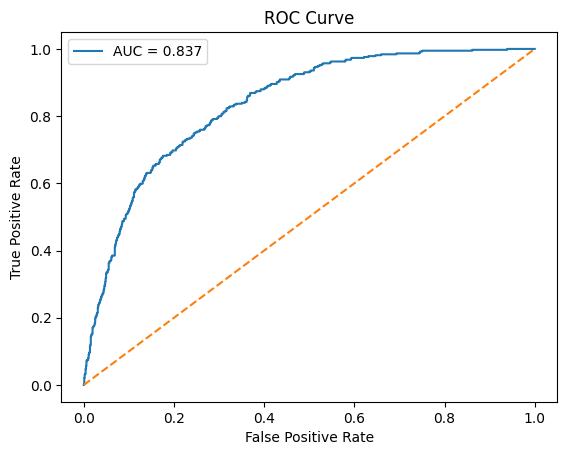

AUC: 0.836503667734805


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", auc)

In [ ]:
new_threshold = 0.3
y_pred_new = (y_prob >= new_threshold).astype(int)

print("Predictions with threshold 0.3:")
print(y_pred_new[:10])

print("\nEffect of changing threshold:")
print("At threshold 0.5:", sum(y_pred), "customers predicted as Churn")
print("At threshold 0.3:", sum(y_pred_new), "customers predicted as Churn")

new_observation = X_test.iloc[[0]]
new_probability = model.predict_proba(new_observation)[0, 1]
new_prediction = int(new_probability >= new_threshold)

print("\nNew observation probability:", new_probability)
print("New observation class:", "Churn" if new_prediction == 1 else "No Churn")